# Crop Classification Model

This notebook takes the final dataset from the satellite notebook and trains a model to predict crop type from it. The goal here isn't to build the fanciest possible model, it's to check whether the NDVI and NDWI patterns alone are actually enough to tell crops apart.

In [1]:
import pandas as pd

field_features = pd.read_csv("../data/field_features.csv")
field_features.head()


,field_id,gewas,crop_class,area_ha,ndvi_apr,ndvi_may,ndvi_jun,ndvi_jul,ndvi_aug,ndvi_sep,...,ndwi_sep,ndwi_oct,ndvi_peak,ndvi_peak_month,ndvi_season_mean,ndvi_range,ndwi_peak,ndwi_peak_month,ndwi_season_mean,ndwi_range
0,0,"Grasland, tijdelijk",Grass,0.766181,0.817539,0.647438,0.580305,0.444897,0.464195,0.643147,...,-0.573292,-0.718762,0.817539,apr,0.628445,0.372642,-0.497035,aug,-0.602143,0.245741
1,1,"Gerst, zomer-",Barley,4.536244,0.464733,0.515721,0.295870,0.431314,0.796887,0.293842,...,-0.345315,-0.424870,0.796887,aug,0.454574,0.503044,-0.345315,sep,-0.475610,0.362625
2,2,"Aardappelen, consumptie",Potato,2.130793,0.349438,0.361585,0.820149,0.871702,0.696163,0.359605,...,-0.435534,-0.359532,0.871702,jul,0.532784,0.600853,-0.359532,oct,-0.551073,0.408600
3,3,"Mais, corncob mix",Maize,0.899990,0.337278,0.328379,0.661381,0.832881,0.743754,0.509124,...,-0.501408,-0.480292,0.832881,jul,0.548048,0.504502,-0.400422,may,-0.547247,0.364193
4,4,"Uien, gele zaai-",Onion,3.651977,0.292880,0.304674,0.455917,0.549658,0.500220,0.349081,...,-0.407066,-0.280463,0.549658,jul,0.390194,0.270732,-0.280463,oct,-0.453151,0.307537


## Quick Data Check

First I check the shape of the dataset, just so I know how many fields and how many columns I'm actually working with before doing anything else.

In [2]:
field_features.shape


(3103, 26)

Then I check how many fields there are per crop class. This matters because models usually do worse on classes that don't have many examples to learn from, so it's good to know this upfront.

In [3]:
field_features["crop_class"].value_counts()


crop_class
Grass         800
Potato        800
Maize         800
Sugar beet    297
Onion         164
Wheat         131
Barley        111
Name: count, dtype: int64

This bar chart makes the class imbalance easier to see at a glance. Grass, maize, and potato have the most fields, while wheat and barley have a lot fewer. Keep this in mind when looking at the results later, since the model had way less to learn from for those smaller classes.

<Axes: title={'center': 'Fields per crop class'}, xlabel='crop_class'>

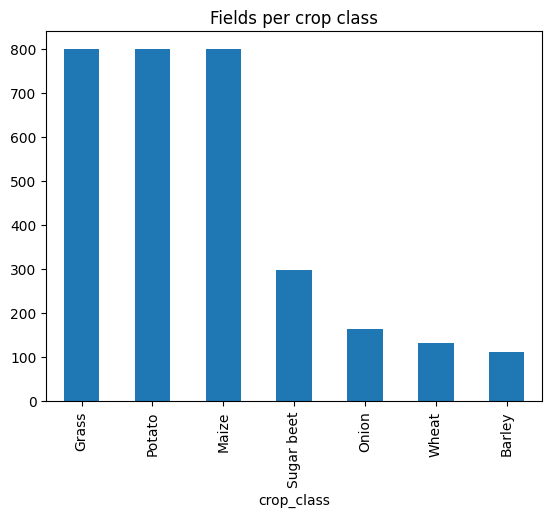

In [4]:
field_features["crop_class"].value_counts().plot(kind="bar", title="Fields per crop class")


## Exploring the Satellite Features

Here I plot the average NDVI curve for each crop class. As a reminder, NDVI is basically a greenness score, so this plot shows how green each crop type tends to be across the growing season.

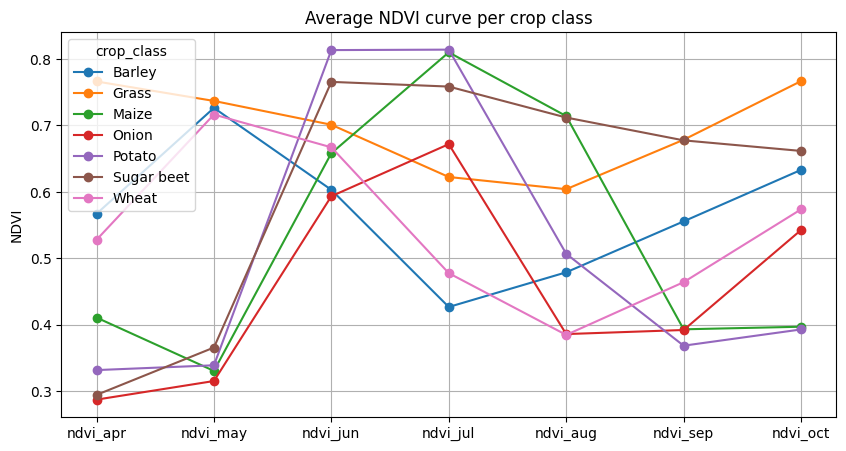

In [5]:
import matplotlib.pyplot as plt

ndvi_cols = ["ndvi_apr", "ndvi_may", "ndvi_jun", "ndvi_jul", "ndvi_aug", "ndvi_sep", "ndvi_oct"]

field_features.groupby("crop_class")[ndvi_cols].mean().T.plot(figsize=(10, 5), marker="o")
plt.title("Average NDVI curve per crop class")
plt.ylabel("NDVI")
plt.grid(True)
plt.show()


Now I do the same thing for NDWI, which is the moisture related signal. Combined with NDVI, this gives the model two different views of how a field changes over the season.

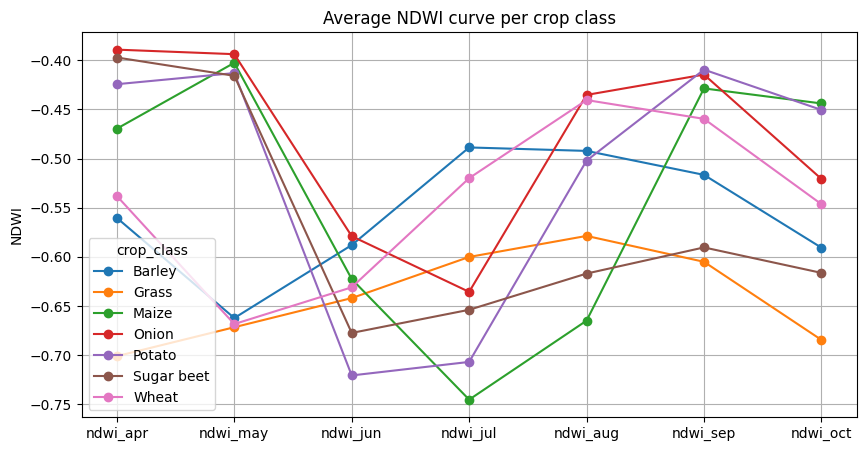

In [6]:
ndwi_cols = ["ndwi_apr", "ndwi_may", "ndwi_jun", "ndwi_jul", "ndwi_aug", "ndwi_sep", "ndwi_oct"]

field_features.groupby("crop_class")[ndwi_cols].mean().T.plot(figsize=(10, 5), marker="o")
plt.title("Average NDWI curve per crop class")
plt.ylabel("NDWI")
plt.grid(True)
plt.show()


## Preparing the Model Data

Here I split the data into inputs (X) and the target (y). The inputs are all the numeric satellite and field features, and the target is the crop class the model is actually trying to predict.

In [7]:
numeric_cols = field_features.select_dtypes("number").columns.tolist()
numeric_cols.remove("field_id")

X = field_features[numeric_cols].fillna(field_features[numeric_cols].median())
y = field_features["crop_class"]

X.head()


,area_ha,ndvi_apr,ndvi_may,ndvi_jun,ndvi_jul,ndvi_aug,ndvi_sep,ndvi_oct,ndwi_apr,ndwi_may,...,ndwi_jul,ndwi_aug,ndwi_sep,ndwi_oct,ndvi_peak,ndvi_season_mean,ndvi_range,ndwi_peak,ndwi_season_mean,ndwi_range
0,0.766181,0.817539,0.647438,0.580305,0.444897,0.464195,0.643147,0.801593,-0.742776,-0.614275,...,-0.499303,-0.497035,-0.573292,-0.718762,0.817539,0.628445,0.372642,-0.497035,-0.602143,0.245741
1,4.536244,0.464733,0.515721,0.295870,0.431314,0.796887,0.293842,0.383652,-0.489983,-0.507482,...,-0.456692,-0.707940,-0.345315,-0.424870,0.796887,0.454574,0.503044,-0.345315,-0.475610,0.362625
2,2.130793,0.349438,0.361585,0.820149,0.871702,0.696163,0.359605,0.270849,-0.458962,-0.451197,...,-0.768131,-0.638192,-0.435534,-0.359532,0.871702,0.532784,0.600853,-0.359532,-0.551073,0.408600
3,0.899990,0.337278,0.328379,0.661381,0.832881,0.743754,0.509124,0.423538,-0.409937,-0.400422,...,-0.764615,-0.667611,-0.501408,-0.480292,0.832881,0.548048,0.504502,-0.400422,-0.547247,0.364193
4,3.651977,0.292880,0.304674,0.455917,0.549658,0.500220,0.349081,0.278926,-0.416159,-0.433493,...,-0.588000,-0.533164,-0.407066,-0.280463,0.549658,0.390194,0.270732,-0.280463,-0.453151,0.307537


I split the data into a training set and a test set. The model only learns from the training set, and then I check how well it does on the test set, fields it has never seen before. This is the standard way to check if a model actually generalizes, instead of just memorizing the data.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

len(X_train), len(X_test)


(2327, 776)

Before training the real model, I calculate a simple baseline first. This is just the accuracy I'd get if I always guessed the most common crop class, no matter what the field actually looks like. It's a sanity check, if my real model can't beat this, it's not actually learning anything useful.

In [9]:
most_common_class = y_train.value_counts().index[0]
baseline_accuracy = (y_test == most_common_class).mean()

baseline_accuracy


np.float64(0.25773195876288657)

## Training the Model

For this first version, I'm using a Random Forest. It's a solid, simple choice for this kind of tabular data (rows and columns, not images or text), and it doesn't need much tuning to get a reasonable result.

In [10]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Model Results

Now I check the accuracy on the test set. This is the simplest measure of how often the model gets the crop type right.

In [11]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy_score(y_test, predictions)


0.9033505154639175

The classification report breaks the result down per crop class. This matters because the overall accuracy can look fine even if some of the smaller classes are actually doing badly, so it's worth checking each one individually.

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

      Barley       0.61      0.61      0.61        28
       Grass       0.95      0.95      0.95       200
       Maize       0.92      0.94      0.93       200
       Onion       0.85      0.85      0.85        41
      Potato       0.91      0.92      0.91       200
  Sugar beet       0.92      0.91      0.91        74
       Wheat       0.74      0.61      0.67        33

    accuracy                           0.90       776
   macro avg       0.84      0.83      0.83       776
weighted avg       0.90      0.90      0.90       776



The confusion matrix shows exactly where the model gets things wrong. For example, if wheat and barley keep getting mixed up with each other, this is where you'd see it.

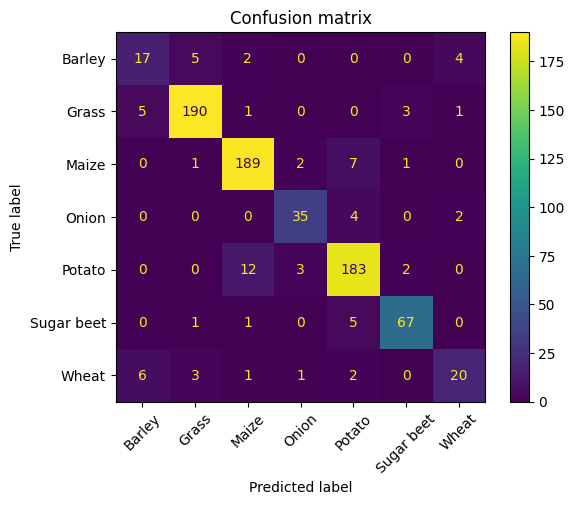

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predictions, xticks_rotation=45)
plt.title("Confusion matrix")
plt.show()


Here I check which features the model actually relied on the most. This is useful to confirm that the monthly NDVI and NDWI values are doing real work, and not just along for the ride.

<Axes: title={'center': 'Most important features'}>

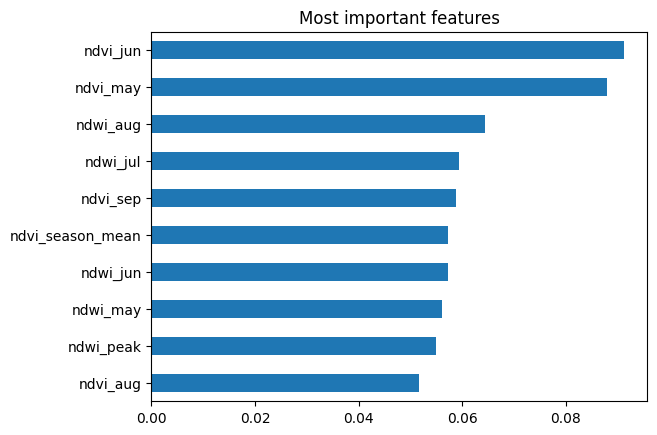

In [14]:
feature_importance = pd.Series(model.feature_importances_, index=numeric_cols).sort_values().tail(10)

feature_importance.plot(kind="barh", title="Most important features")


## Example Predictions

Lastly, I look at a handful of random test fields and compare the real crop class to what the model predicted. This makes the result feel a lot more concrete than just looking at one accuracy number.

In [15]:
results = field_features.loc[X_test.index, ["field_id", "gewas", "crop_class"]].copy()
results["prediction"] = predictions
results["correct"] = results["crop_class"] == results["prediction"]

results.sample(10, random_state=42)


,field_id,gewas,crop_class,prediction,correct
408,408,"Mais, snij-",Maize,Maize,True
469,469,"Aardappelen, consumptie",Potato,Potato,True
1936,1936,"Gerst, zomer-",Barley,Wheat,False
1156,1156,"Grasland, tijdelijk",Grass,Grass,True
1725,1725,"Bieten, suiker-",Sugar beet,Sugar beet,True
815,815,"Aardappelen, consumptie",Potato,Potato,True
1881,1881,"Mais, snij-",Maize,Maize,True
743,743,"Tarwe, zomer-",Wheat,Wheat,True
2262,2262,"Grasland, blijvend",Grass,Grass,True
2758,2758,"Grasland, tijdelijk",Grass,Grass,True


## Saving the Model

Now I save this trained model to a file, so the app can load it directly instead of having to retrain it every time it starts up.

In [16]:
import joblib

joblib.dump(model, "../model.pkl")
print("Saved model to ../model.pkl")

Saved model to ../model.pkl
